In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from edge_detection import *
from line_detection import *
from nfa import validate_lines
import os

In [2]:
dataset_path = "../images/dataset_complex_case/"
images = [f for f in os.listdir(dataset_path) if f.endswith(".jpg")]
print(len(images))

5


In [3]:
def apply_pipeline(path, at=1, eps=1.0):
    img = cv2.imread(path,0)
    smooth = gaussian_smoothing(img)
    G, D = compute_gradient(smooth)
    anchors = compute_anchors(G,D, anchor_threshold=at)
    edges = edge_drawing(G, D, anchors)
    lines = detect_lines(edges)
    
    gx_map = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=1)
    gy_map = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=1)

    valid_lines = validate_lines(lines, gx_map, gy_map, img.shape, eps=eps)

    return img, edges, valid_lines
    

In [4]:
results = []
mean_lines = []

for name in images:

    path = os.path.join(dataset_path, name)

    img, edges, valid = apply_pipeline(path)

    results.append({
        "image": name,
        "edges": len(edges),
        "valid_lines": len(valid)
    })

    mean_lines.append(len(valid))

    print(name, "edges:", len(edges), "valid:", len(valid))

print(f"Mean number of lines for this dataset : {np.mean(mean_lines)}")

4.jpg edges: 170 valid: 87
5.jpg edges: 419 valid: 37
2.jpg edges: 2041 valid: 273
3.jpg edges: 780 valid: 148
1.jpg edges: 368 valid: 62
Mean number of lines for this dataset : 121.4


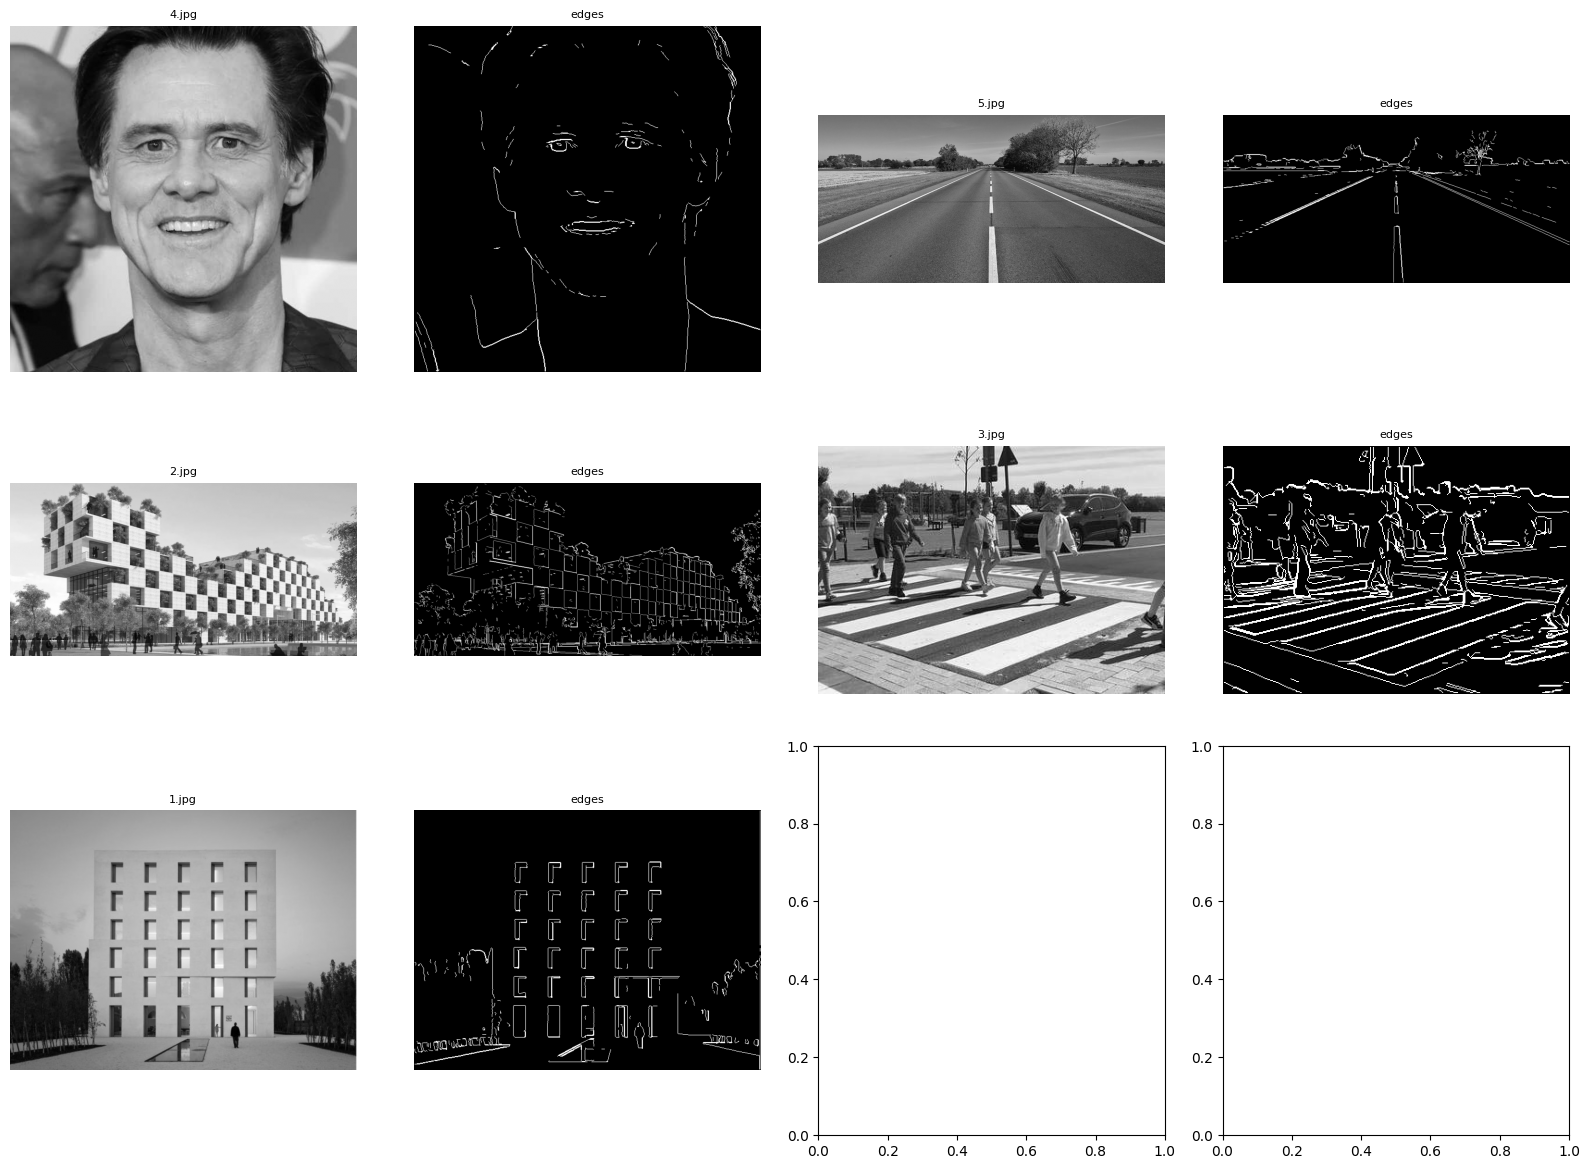

In [6]:
n = len(images)
cols = 2
rows = int(np.ceil(n / cols))

fig, ax = plt.subplots(rows, cols*2, figsize=(4*cols*2, 4*rows))

for i, name in enumerate(images):

    path = os.path.join(dataset_path, name)

    img, edges, valid_lines = apply_pipeline(path)

    edge_img = np.zeros_like(img)

    for edge in edges:
        edge = np.array(edge)
        edge_img[edge[:,0], edge[:,1]] = 255

    r = i // cols
    c = (i % cols) * 2

    ax[r, c].imshow(img, cmap="gray")
    ax[r, c].set_title(name, fontsize=8)
    ax[r, c].axis("off")

    ax[r, c+1].imshow(edge_img, cmap="gray")
    ax[r, c+1].set_title("edges", fontsize=8)
    ax[r, c+1].axis("off")

plt.tight_layout()
plt.show()

# Try different parameters

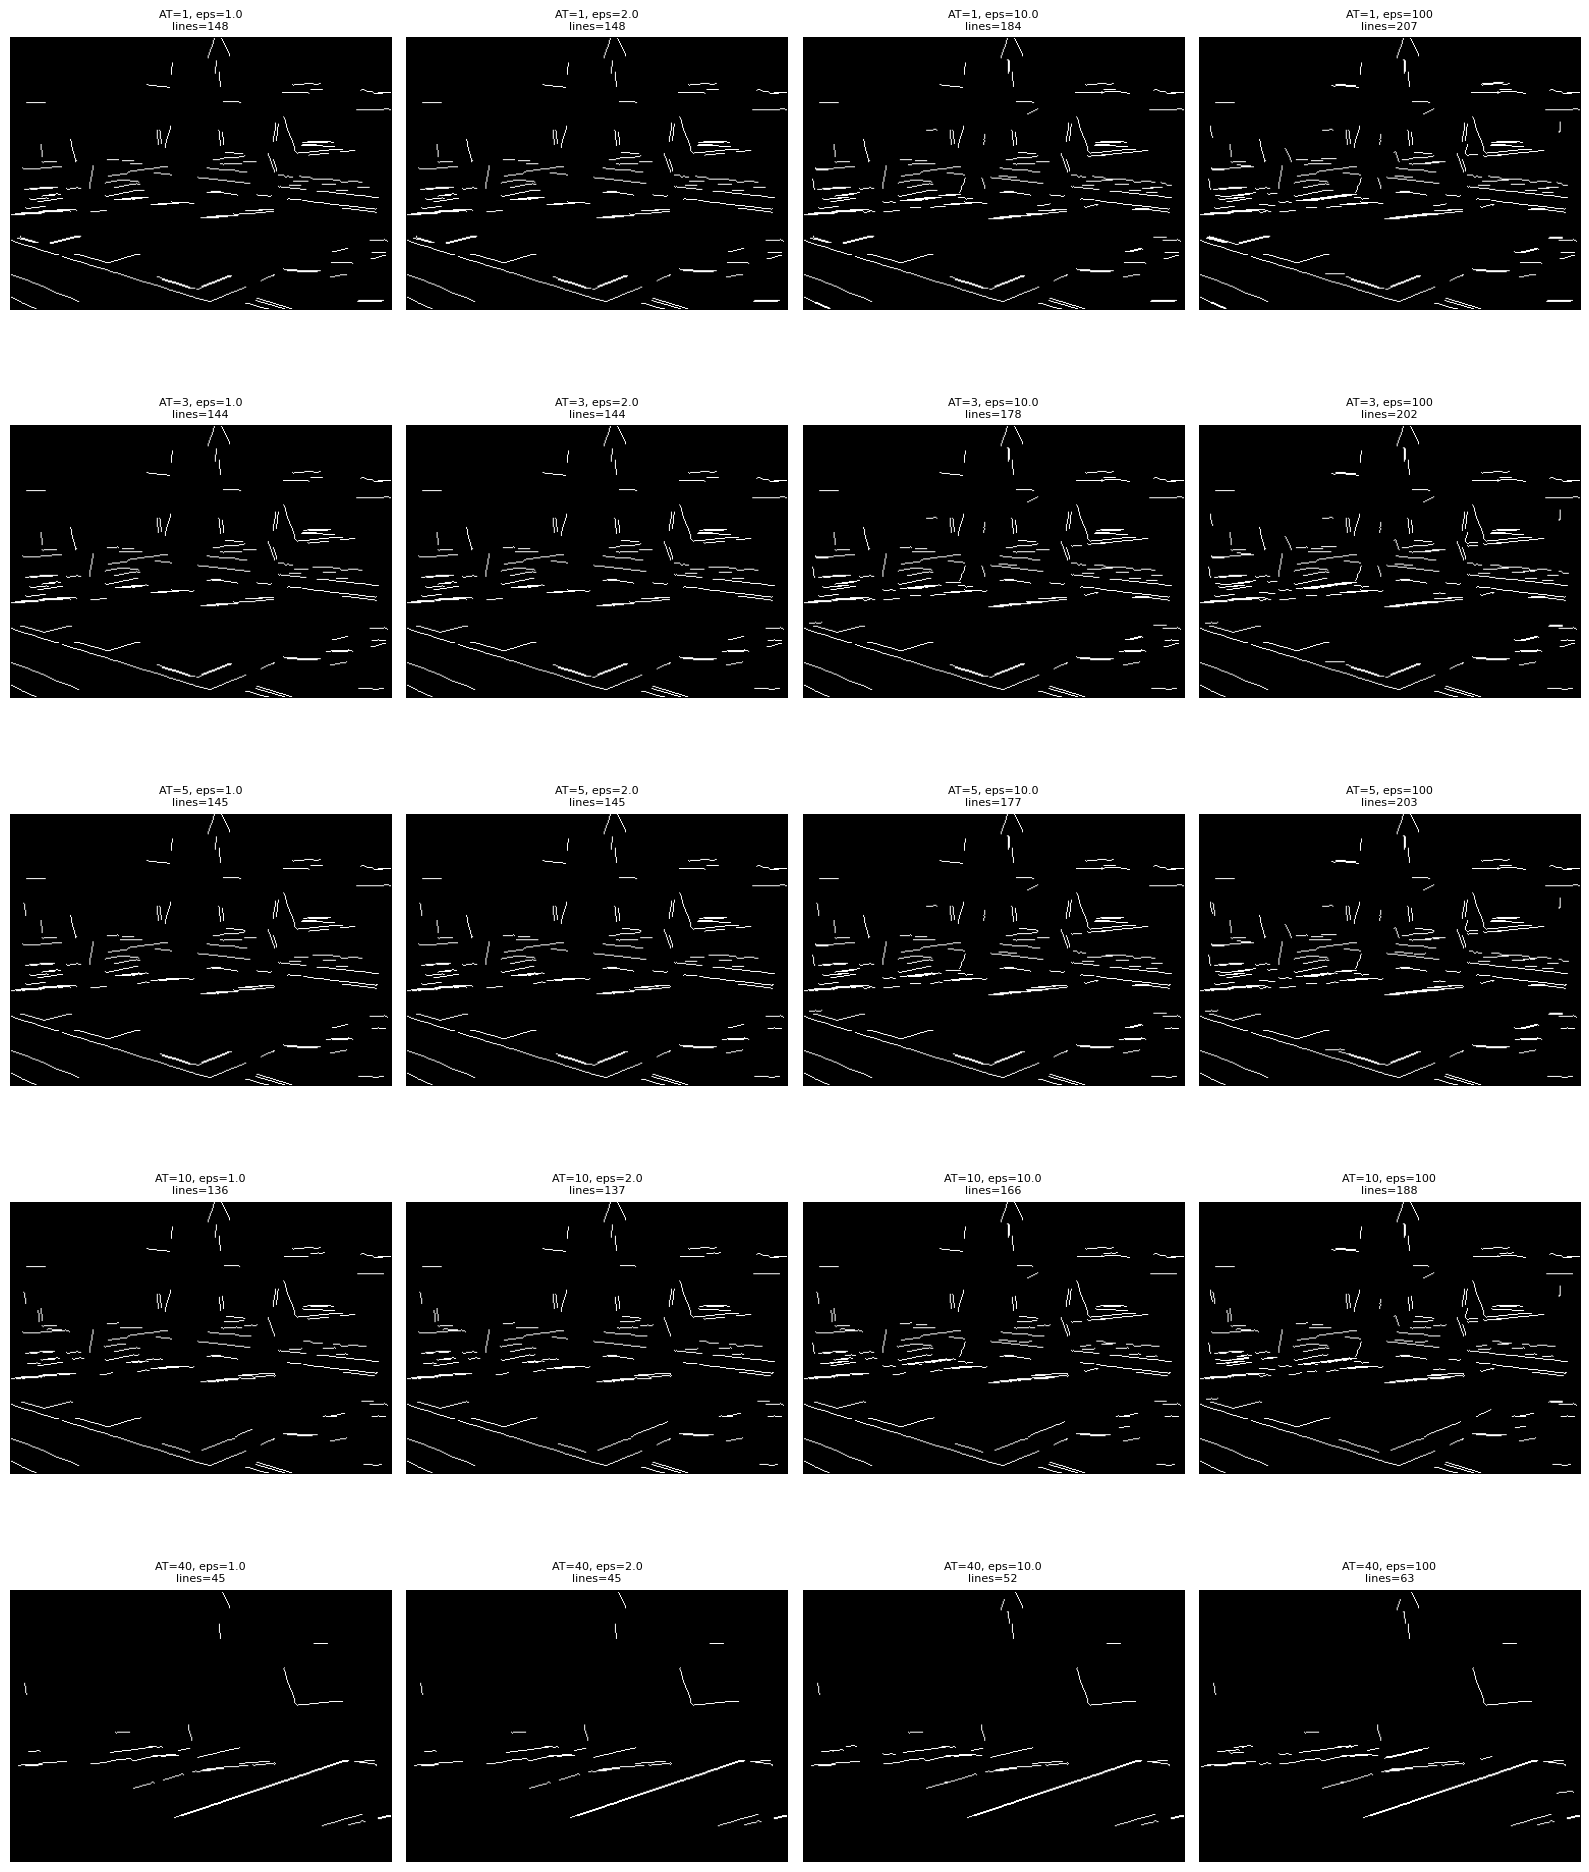

In [12]:
image_name = images[3]
path = os.path.join(dataset_path, image_name)

anchor_thresholds = [1, 3, 5, 10, 40]
eps_values = [1.0, 2.0, 10.0, 100]

rows = len(anchor_thresholds)
cols = len(eps_values)

fig, ax = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))

for i, at in enumerate(anchor_thresholds):
    for j, eps in enumerate(eps_values):

        img, edges, valid_lines = apply_pipeline(path, at=at, eps=eps)

        line_img = np.zeros_like(img)

        for line in valid_lines:
            line = np.array(line)
            line_img[line[:,0], line[:,1]] = 255

        ax[i, j].imshow(line_img, cmap="gray")
        ax[i, j].set_title(f"AT={at}, eps={eps}\nlines={len(valid_lines)}", fontsize=8)
        ax[i, j].axis("off")

plt.tight_layout()
plt.show()